In [1]:
import numpy as np
import matplotlib.pyplot as plt
from UQpy.sampling.ThetaCriterionPCE import *

from UQpy.distributions import Uniform, JointIndependent, Normal
from UQpy.surrogates import *

from UQpy.sampling import LatinHypercubeSampling
from UQpy.sampling.stratified_sampling.latin_hypercube_criteria import *
import matlab.engine
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

from Theta import ThetaCriterionPCE

In [2]:
## Mirror function (multi-output version)

# Single model
def Model2D1(X, delta=0.1):
    M = X[:, 0] < X[:, 1]
    base = 1/(np.abs(0.3 - X[:,0]**2 - X[:,1]**2) + delta) \
         - 1/(np.abs(0.3 - (1-X[:,0])**2 - (1-X[:,1])**2) + delta)
    Y = base.copy()
    Y[~M] = 0.0
    return Y

def Model2D2(X, delta=0.1, scale=0.1):
    M = X[:, 0] > X[:, 1]
    base = 1/(np.abs(0.3 - X[:,0]**2 - X[:,1]**2) + delta) \
         - 1/(np.abs(0.3 - (1-X[:,0])**2 - (1-X[:,1])**2) + delta)
    Y = scale * base
    Y[~M] = 0.0
    return Y


# Complete model
def Model2DComplete(X, delta=0.1):
    Y = Model2D1(X) + Model2D2(X)
    return Y

In [3]:
## Input distribution

dist1 = Uniform(loc=0, scale=1)
dist2 = Uniform(loc=0, scale=1)

marg = [dist1, dist2]
joint = JointIndependent(marginals=marg)

In [4]:
## Polynomial setting

P = 10
polynomial_basis_1 = TotalDegreeBasis(joint, P)
polynomial_basis_2 = TotalDegreeBasis(joint, P)

## Regression
least_squares = LeastSquareRegression()

In [5]:
## Initial sample

np.random.seed(99)
sample_size = 10

xx_train = joint.rvs(sample_size)
yy_train1 = Model2D1(xx_train)
yy_train2 = Model2D2(xx_train)

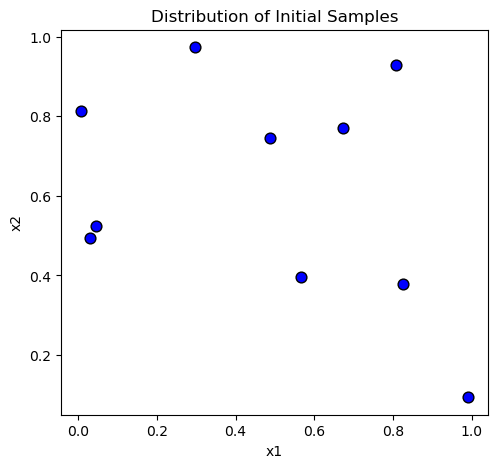

In [6]:
## Initial sample plotting

plt.figure(figsize=(5.5, 5))
plt.scatter(xx_train[:, 0], xx_train[:, 1], c='blue', edgecolor='k', s=60)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Distribution of Initial Samples')
plt.show()

In [7]:
## Candidates setting

n_cand = 10000

lhs_maximin_cand = LatinHypercubeSampling(distributions=[dist1, dist2],
                                          criterion=MaxiMin(metric=DistanceMetric.CHEBYSHEV),
                                          nsamples=n_cand)

Xaptive = lhs_maximin_cand._samples

In [8]:
## Safe function for LAR (back to OLS if fail)

def safe_model_selection(pce_obj):
    try:
        return polynomial_chaos.regressions.LeastAngleRegression.model_selection(pce_obj)
    except Exception:
        return pce_obj

In [9]:
## Theta

# Initial design
rng = np.random.default_rng(25)
Xadapted = xx_train.copy()
Yadapted1 = yy_train1.copy()
Yadapted2 = yy_train2.copy()

# Adaptive sampling
total_add = 490

for i in range(total_add):
    
    # Fit PCE for output 1
    pce1 = PolynomialChaosExpansion(
        polynomial_basis=polynomial_basis_1,
        regression_method=least_squares
    )

    pce1.fit(Xadapted, Yadapted1)
    pceLAR1 = safe_model_selection(pce1)
    
    # Fit PCE for output 2
    pce2 = PolynomialChaosExpansion(
        polynomial_basis=polynomial_basis_2,
        regression_method=least_squares
    )

    pce2.fit(Xadapted, Yadapted2)
    pceLAR2 = safe_model_selection(pce2)

    # Multi-output Theta selection
    ThetaSampling = ThetaCriterionPCE([
        pceLAR1,
        pceLAR2
    ])

    k = ThetaSampling.run(
        existing_samples=Xadapted,
        candidate_samples=Xaptive,
        nsamples=1
    )

    # Add new sample
    x_new = Xaptive[k:k + 1, :]
    y1_new = Model2D1(x_new)
    y2_new = Model2D2(x_new)

    Xadapted = np.vstack([
        Xadapted,
        x_new
    ])

    Yadapted1 = np.r_[
        Yadapted1,
        y1_new
    ]

    Yadapted2 = np.r_[
        Yadapted2,
        y2_new
    ]

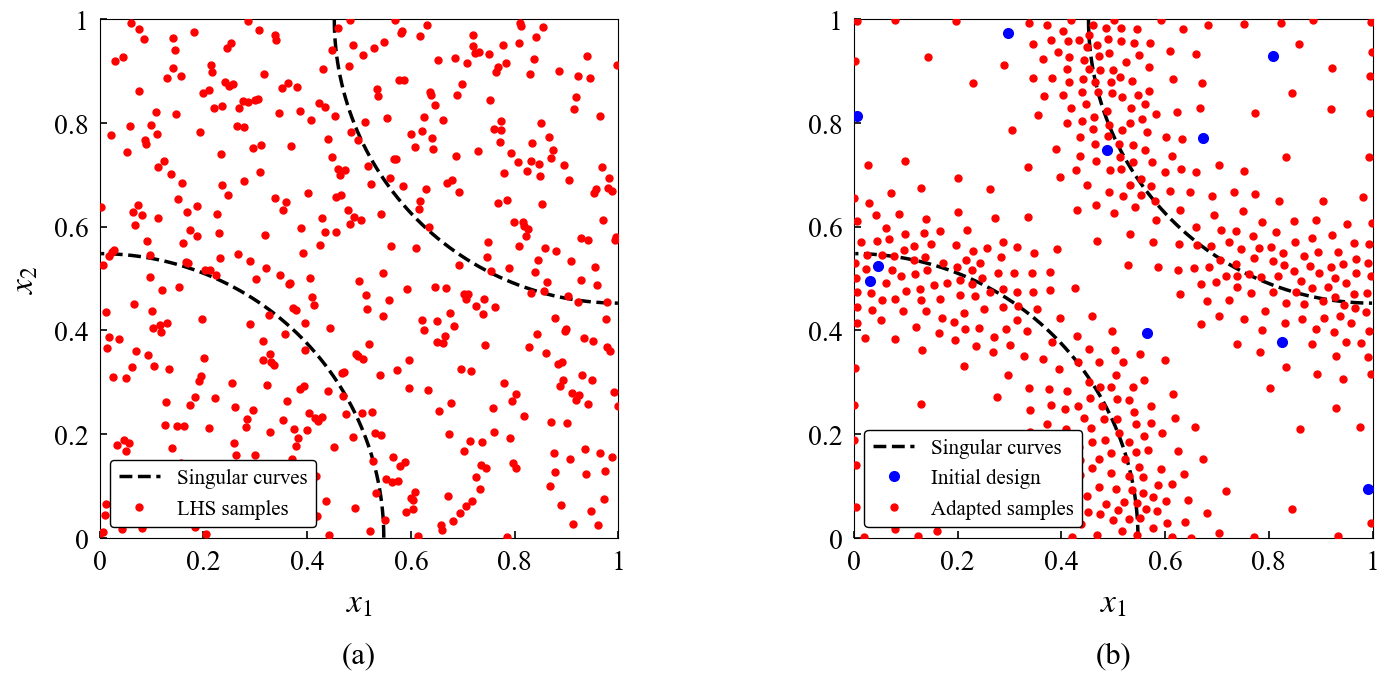

In [10]:
## ploting
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 15
})

def tick_formatter(x, pos):
    if np.isclose(x, round(x)):
        return f"{int(round(x))}"
    return f"{x:.1f}"

formatter = FuncFormatter(tick_formatter)

n_total = Xadapted.shape[0]
X_theta_plot = Xadapted[:n_total]

# LHS for comparison
lhs_design = LatinHypercubeSampling(
    distributions=[dist1, dist2],
    nsamples=n_total,
    random_state=99
)
X_lhs = lhs_design._samples


# Singular curves
r = np.sqrt(0.3)
theta = np.linspace(0, 2 * np.pi, 1000)

x1_c1 = r * np.cos(theta)
x2_c1 = r * np.sin(theta)

x1_c2 = 1 + r * np.cos(theta)
x2_c2 = 1 + r * np.sin(theta)

mask1 = (
    (x1_c1 >= 0) & (x1_c1 <= 1) &
    (x2_c1 >= 0) & (x2_c1 <= 1)
)

mask2 = (
    (x1_c2 >= 0) & (x1_c2 <= 1) &
    (x2_c2 >= 0) & (x2_c2 <= 1)
)

# Comparison
fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.2), sharex=True, sharey=True)

# (a) LHS design
ax = axes[0]

sing_line_lhs, = ax.plot(
    x1_c1[mask1], x2_c1[mask1],
    'k--',
    linewidth=2.5,
    label='Singular curves',
    zorder=1
)

ax.plot(
    x1_c2[mask2], x2_c2[mask2],
    'k--',
    linewidth=2.5,
    zorder=1
)

lhs_pts, = ax.plot(
    X_lhs[:, 0], X_lhs[:, 1],
    'ro',
    markersize=5.0,
    label='LHS samples',
    zorder=4
)

ax.set_xlabel(r"$x_1$", labelpad=10)
ax.set_ylabel(r"$x_2$", labelpad=10)

ax.legend(
    handles=[sing_line_lhs, lhs_pts],
    loc='lower left',
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1.0
)

ax.text(
    0.5, -0.20,
    r"(a)",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=22
)

# (b) Theta design
ax = axes[1]

sing_line_theta, = ax.plot(
    x1_c1[mask1], x2_c1[mask1],
    'k--',
    linewidth=2.5,
    label='Singular curves',
    zorder=1
)

ax.plot(
    x1_c2[mask2], x2_c2[mask2],
    'k--',
    linewidth=2.5,
    zorder=1
)

adapted_pts, = ax.plot(
    X_theta_plot[:, 0], X_theta_plot[:, 1],
    'ro',
    markersize=5.0,
    label='Adapted samples',
    zorder=4
)

n_init_show = min(len(xx_train), len(X_theta_plot))

initial_pts, = ax.plot(
    X_theta_plot[:n_init_show, 0],
    X_theta_plot[:n_init_show, 1],
    'bo',
    markersize=7.0,
    label='Initial design',
    zorder=5
)

ax.set_xlabel(r"$x_1$", labelpad=10)

ax.legend(
    handles=[sing_line_theta, initial_pts, adapted_pts],
    loc='lower left',
    frameon=True,
    facecolor='white',
    edgecolor='black',
    framealpha=1.0
)

ax.text(
    0.5, -0.20,
    r"(b)",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=22
)


for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    ax.tick_params(
        direction='in',
        length=5,
        width=1.2,
        pad=8
    )

    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

axes[1].tick_params(labelleft=True)


plt.tight_layout()
plt.subplots_adjust(
    bottom=0.23,
    wspace=0.18
)

plt.savefig("lhs_vs_theta_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()